In [ ]:
###
    # This code plot the constrained sensivity of permafrost area under climate change, derived from seasonal soil temperature sensitivity
    # Same with Figure 1, but grouped by different model families.
    # Output: Figure S14.
###

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols
from scipy.stats import pearsonr
from math import sqrt
import string
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

In [ ]:
# The function of group model
def group_mean(ss, fs, models, groups):
    ss = np.array(ss)
    fs = np.array(fs)

    group_ss = []
    group_fs = []
    group_names = []

    for gname, gmodels in groups.items():
        idx = [i for i, m in enumerate(models) if m in gmodels]
        if len(idx) == 0:
            continue

        group_ss.append(np.mean(ss[idx]))
        group_fs.append(np.mean(fs[idx]))
        group_names.append(gname)

    return np.array(group_ss), np.array(group_fs), group_names

# The function of plot
def plot_sensitivity(obsmean, obsstd, ss, fs, model,model_groups, i, j):
    # Convert input ss and fs to numpy arrays
    ss = np.array(ss, dtype=np.float64)
    fs = np.array(fs, dtype=np.float64).flatten()

    # === NEW: group-based statistics ===
    g_ss, g_fs, g_names = group_mean(ss, fs, model, model_groups)

    xmean = np.mean(g_ss)
    xstd = np.std(g_ss)
    zmean = np.mean(g_fs)
    zstd = np.std(g_fs)
    
    # Create DataFrame and sort
    df = pd.DataFrame({'x': g_ss, 'y': g_fs})
    df = df.sort_values('x')
    
    # Perform linear regression
    ols_model = ols('y ~ x', data=df).fit()
    r, p_value = pearsonr(g_ss, g_fs)
    pred = ols_model.get_prediction(df)
    pred_summary = pred.summary_frame(alpha=0.05)

    print("Group means:")
    for name, val in zip(g_names, g_fs):
        print(f"{name}: {val:.3f}")

    print('zmean (group) = ' + str(round(zmean, 2)))
    print('zstd (group) = ' + str(round(zstd, 2)))

    # Calculate the forecasted value with emerging constraints
    zmean_EC = zmean + r * zstd * xstd * (obsmean - xmean) / (xstd**2 + obsstd**2)
    zstd_EC = sqrt(1 - r**2 / (1 + obsstd**2 / xstd**2)) * zstd
    print('zmean_EC = ' + str(round(zmean_EC, 4)))
    print('zstd_EC = ' + str(round(zstd_EC, 4)))
    print('RCM ' +str(round(((zmean_EC-zmean)/zmean)*100,2))+'%')
    print('RRV ' +str(round((1-zstd_EC*zstd_EC/zstd/zstd)*100,2))+'%')

    tem = ["1.5°C", "2°C", "3°C"]
    row_title = ["1.6m", "2.4m", "3.2m"]
    letters = list(string.ascii_lowercase) 
    
    ax = axs[i, j]
    
    # Set labels for subplots
    ax.text( -0.18, 1.04,  
            f"{letters[3*i+j]}",
            transform=ax.transAxes, 
            fontproperties=FontProperties(weight='bold', size=11),
            verticalalignment='bottom',
            color='black')
    if i == 2 and j == 1:
        x_labels = ["Seasonal sensitivity of soil temperature (°C/°C)"]
        ax.set_xlabel(x_labels[0], labelpad=12, fontsize=14)
    if i == 1 and j == 0:
        y_labels = ["Sensitivity of permafrost loss to global warming (%/°C)"]
        ax.set_ylabel(y_labels[0], labelpad=43, fontsize=14)
    if i == 0:
        ax.set_title(row_title[j], fontsize=12, c='black')

    if j == 0:
        ax.text(-0.27, 0.5, tem[i], va='center', ha='right', rotation='vertical', 
                   fontsize=12, transform=ax.transAxes)

    colors = plt.cm.tab10(np.linspace(0, 1, 10))[:9]        # Generate color list using colormap
    markers = ['o', 's', '^','4','H','*','>','2','+']
    ax.plot(df['x'].values, pred_summary['mean'].values, color='blue', linewidth=1.6, linestyle='--')

    # Plot scatter plot
    h = 0
    for s, f, color, model in zip(g_ss, g_fs, colors, g_names):
        if h % 3 == 0:
            ax.scatter(s, f, color=color, marker=markers[h], s=55, label=model)
        elif h % 3 == 1:
            ax.scatter(s, f, color=color, marker=markers[h], s=55, label=model)
        else:
            ax.scatter(s, f, color=color, marker=markers[h], s=55, label=model)
        h = h + 1

    if j == 0:
        ax.set_ylim(-105,0)
        ax.set_xlim(0.18,0.61)
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.02))
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
        ax.yaxis.set_minor_locator(plt.MultipleLocator(4))
        ax.yaxis.set_major_locator(plt.MultipleLocator(20))
        ax.tick_params(axis='both', which='major', labelsize=11)
        ax.tick_params(axis='both', which='minor', length=2, color='black')
        ax.plot([np.max(ss) + 0.02, np.max(ss) + 0.02], [zmean - zstd, zmean + zstd], color='blue', linewidth=2)
        ax.scatter(np.max(ss) + 0.02, zmean, color='blue', s=30)
        ax.scatter(np.max(ss) + 0.035, zmean_EC, color='black', s=30)
        ax.plot([np.max(ss) + 0.035, np.max(ss) + 0.035], [zmean_EC - zstd_EC, zmean_EC + zstd_EC], color='black', linewidth=2)
    elif j == 1:
        ax.set_ylim(-67, -5)
        ax.set_xlim(0.13,0.44)
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.02))
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
        ax.yaxis.set_minor_locator(plt.FixedLocator(np.arange(-67, -5, 2)))
        ax.yaxis.set_major_locator(plt.MultipleLocator(10))
        ax.tick_params(axis='both', which='major', labelsize=11)
        ax.tick_params(axis='both', which='minor', length=2, color='black')
        ax.set_yticks(np.arange(-70, -5, 10) + 5)
        ax.set_yticklabels([str(m) for m in range(-65, 0, 10)], color='black') 
        ax.plot([np.max(ss) + 0.02, np.max(ss) + 0.02], [zmean - zstd, zmean + zstd], color='blue', linewidth=2)
        ax.scatter(np.max(ss) + 0.02, zmean, color='blue', s=30)
        ax.scatter(np.max(ss) + 0.032, zmean_EC, color='black', s=30)
        ax.plot([np.max(ss) + 0.032, np.max(ss) + 0.032], [zmean_EC - zstd_EC, zmean_EC + zstd_EC], color='black', linewidth=2)
    else:
        ax.set_ylim(-47,-5)
        ax.set_xlim(0.1,0.352)
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.02))
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
        ax.yaxis.set_minor_locator(plt.FixedLocator(np.arange(-47, -5, 2)))
        ax.yaxis.set_major_locator(plt.MultipleLocator(10))
        ax.tick_params(axis='both', which='major', labelsize=11)
        ax.tick_params(axis='both', which='minor', length=2, color='black')
        ax.set_yticks(np.arange(-50, -5, 10) + 5)
        ax.set_yticklabels([str(m) for m in range(-45, 0, 10)], color='black') 
        ax.plot([np.max(ss) + 0.014, np.max(ss) + 0.014], [zmean - zstd, zmean + zstd], color='blue', linewidth=2)
        ax.scatter(np.max(ss) + 0.014, zmean, color='blue', s=30)
        ax.scatter(np.max(ss) + 0.024, zmean_EC, color='black', s=30)
        ax.plot([np.max(ss) + 0.024, np.max(ss) + 0.024], [zmean_EC - zstd_EC, zmean_EC + zstd_EC], color='black', linewidth=2)
    ylim = ax.get_ylim()
    ax.plot([obsmean, obsmean], [ylim[0], ylim[0] + 0.94 * (ylim[1] - ylim[0])], color='black', linewidth=1.5, linestyle='--')
    ax.text(obsmean, ylim[0] + 0.97 * (ylim[1] - ylim[0]), "obs", ha='center', va='center', fontsize=10)
    ax.fill_betweenx([ylim[0], ylim[0] + 0.94 * (ylim[1] - ylim[0])], obsmean - obsstd, obsmean + obsstd, color='gray', alpha=0.3)        
    ax.set_ylim(ylim[0], ylim[1])  
    
    if i == 2 and j == 1:
        ax.legend(loc='upper center', bbox_to_anchor=(0.46, -0.31), edgecolor='lightgrey', shadow=False, ncol=5, fontsize=11)
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = ''                  # Do not display asterisks when the result is not statistically significant

    # Add correlation coefficient and statistical significance to the plot
    ax.text(0.04, 0.1,f"$R = {r:.2f}${significance}", ha='left', va='center', transform=ax.transAxes, fontsize=10)
    ax.grid(True, linestyle='--', linewidth=1, alpha=0.2)
    return fig

160cm
Group means:
CESM: -31.828
CNRM: -41.341
FGOALS: -35.015
GFDL: -18.612
MIROC: -30.712
MPI: -95.699
NorESM: -31.983
E3SM: -51.796
TaiESM: -36.403
zmean (group) = -41.49
zstd (group) = 20.91
zmean_EC = -51.1184
zstd_EC = 12.2281
RCM 23.21%
RRV 65.81%
Group means:
CESM: -31.118
CNRM: -40.056
FGOALS: -36.876
GFDL: -17.905
MIROC: -30.328
MPI: -74.577
NorESM: -30.479
E3SM: -49.756
TaiESM: -31.622
zmean (group) = -38.08
zstd (group) = 15.23
zmean_EC = -45.0731
zstd_EC = 8.9621
RCM 18.37%
RRV 65.39%
Group means:
CESM: -27.485
CNRM: -33.676
FGOALS: -31.605
GFDL: -18.620
MIROC: -29.838
MPI: -43.649
NorESM: -27.886
E3SM: -36.453
TaiESM: -28.524
zmean (group) = -30.86
zstd (group) = 6.5
zmean_EC = -33.6651
zstd_EC = 4.2171
RCM 9.09%
RRV 57.86%
240cm
Group means:
CESM: -26.942
CNRM: -20.241
FGOALS: -23.293
GFDL: -16.568
MIROC: -28.165
MPI: -43.332
NorESM: -27.730
E3SM: -35.876
TaiESM: -25.976
zmean (group) = -27.57
zstd (group) = 7.56
zmean_EC = -32.3887
zstd_EC = 4.1811
RCM 17.48%
RRV 69.38%

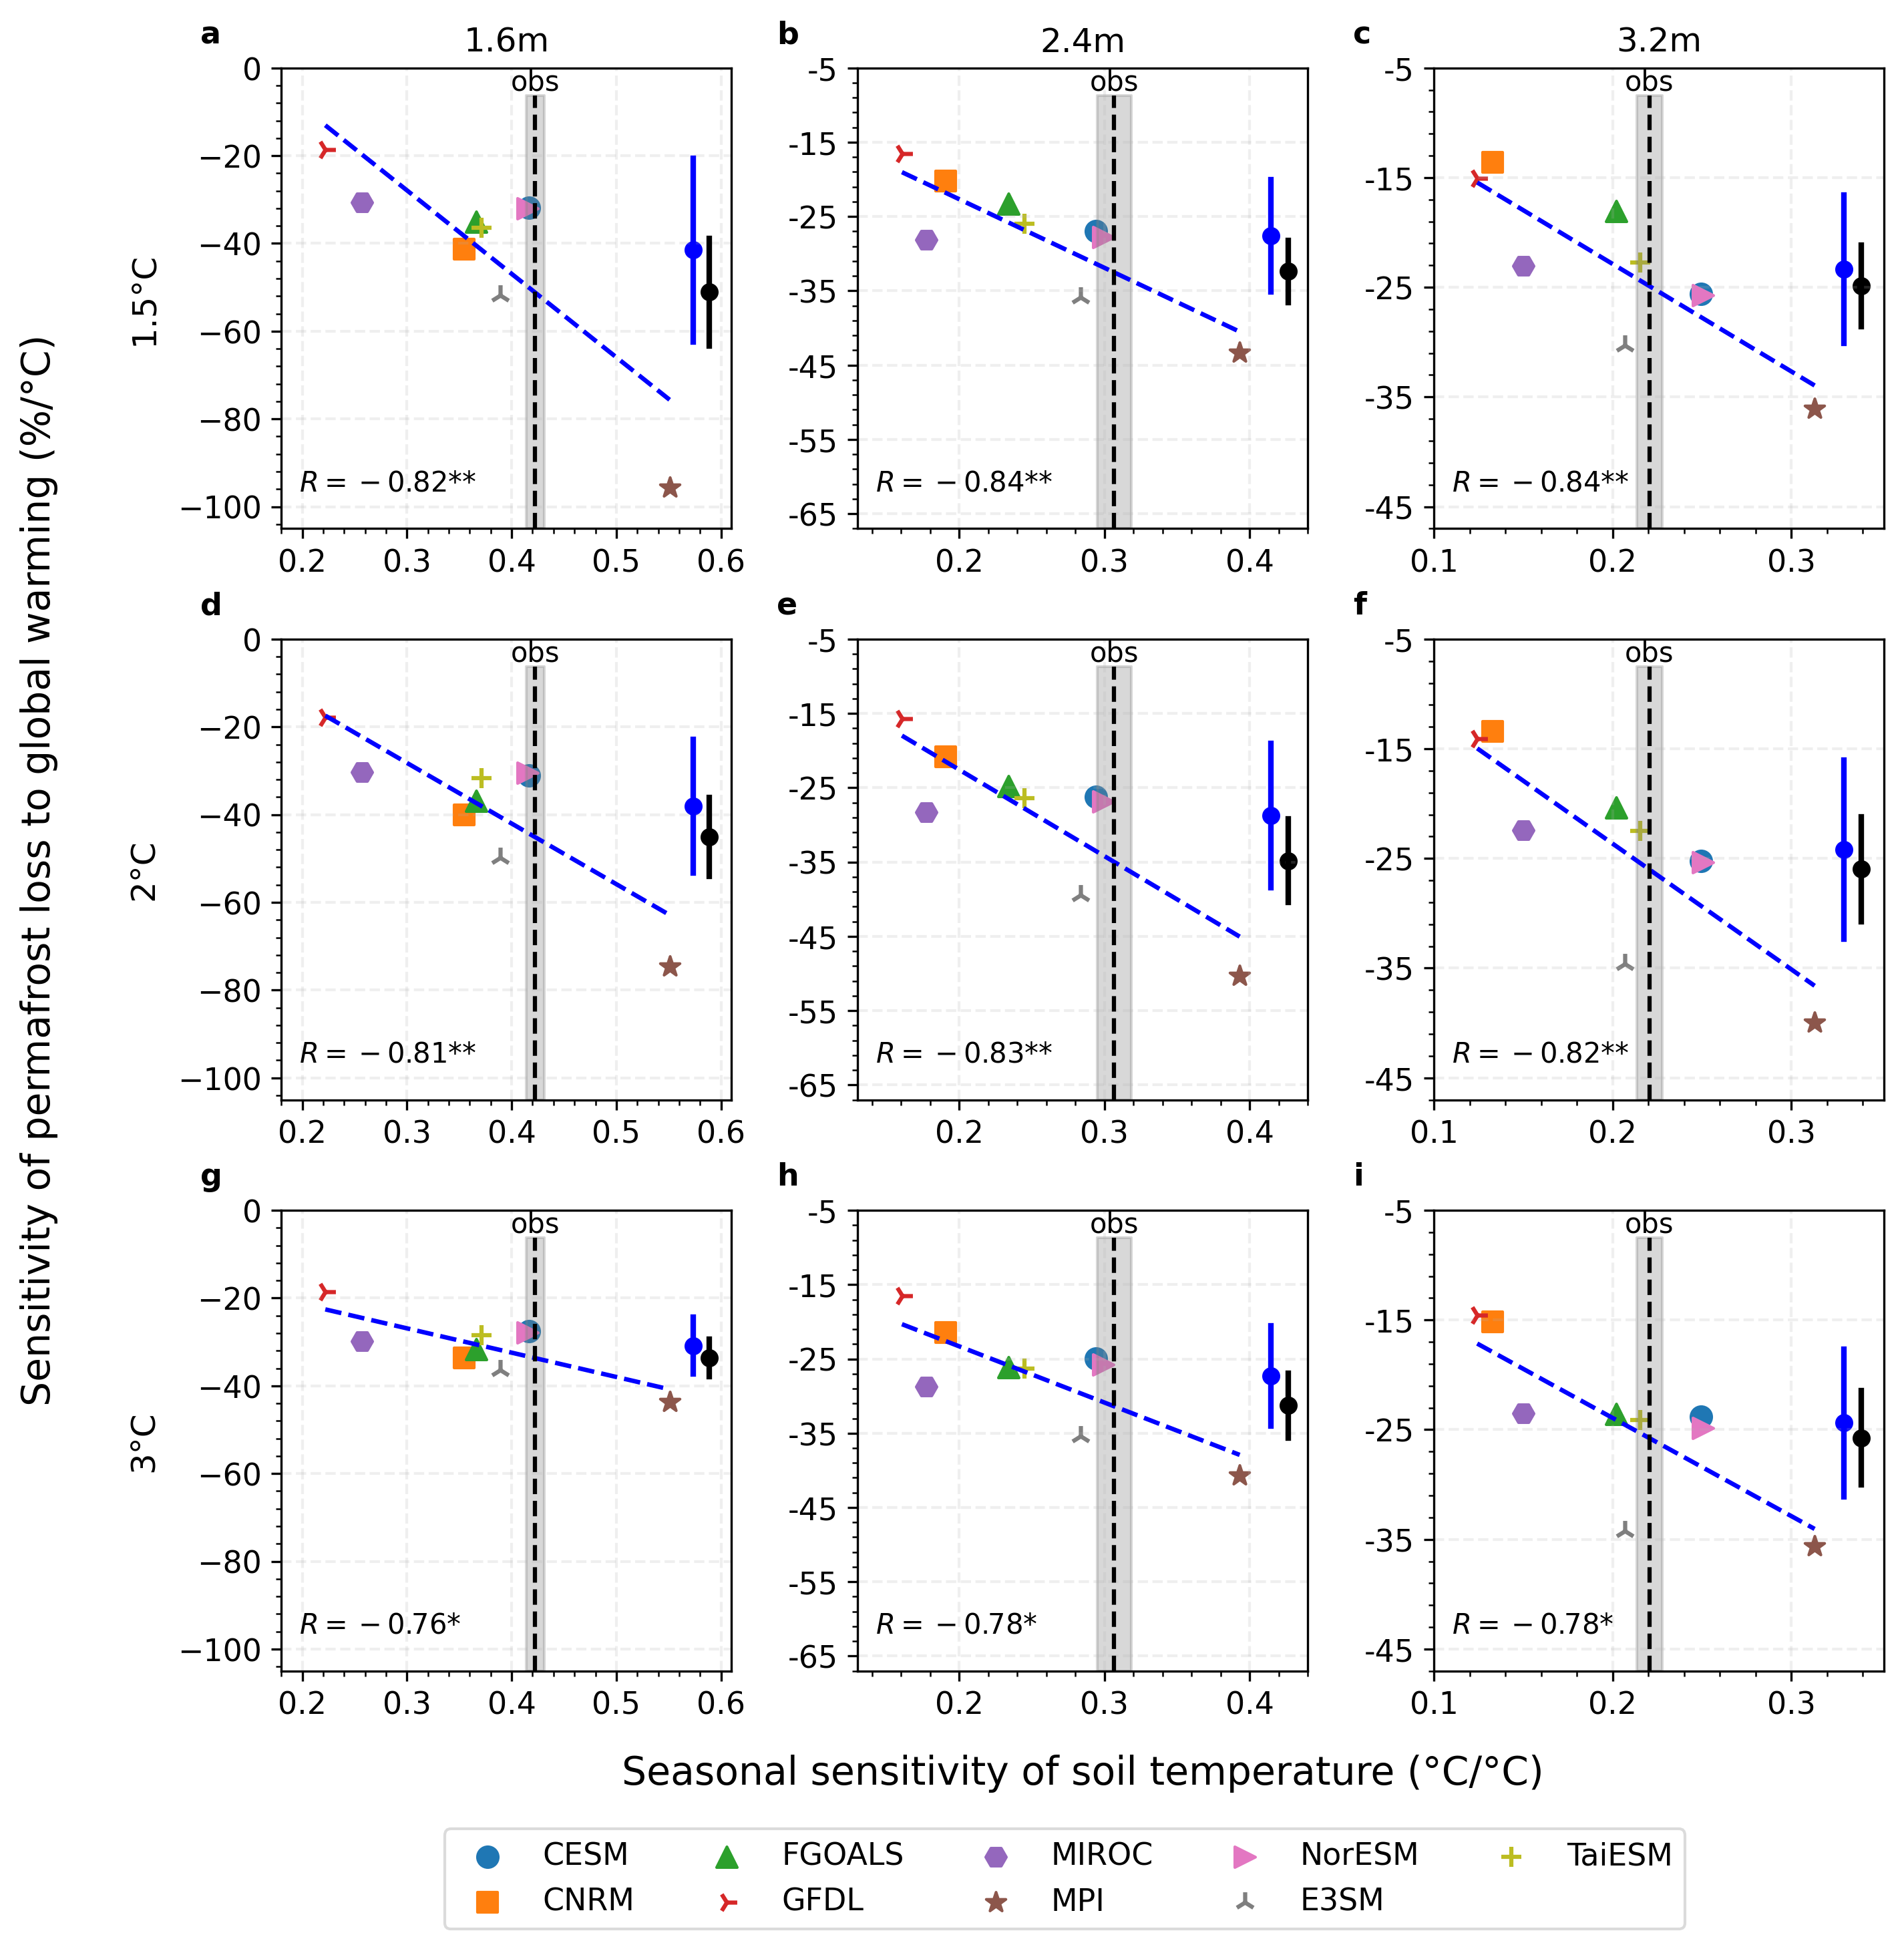

In [ ]:
model_order = ["CESM2","CESM2-FV2","CESM2-WACCM","CNRM-CM6-1-HR","CNRM-CM6-1","CNRM-ESM2-1",
               "E3SM-1-1","FGOALS-f3-L","FGOALS-g3","GFDL-CM4","GFDL-ESM4","MIROC6",
               "MIROC-ES2L","MPI-ESM1-2-HR","MPI-ESM1-2-LR","NorESM2-LM","NorESM2-MM","TaiESM1"]
model_groups = {
    "CESM": ["CESM2","CESM2-FV2","CESM2-WACCM"],
    "CNRM": ["CNRM-CM6-1-HR","CNRM-CM6-1","CNRM-ESM2-1"],
    "FGOALS": ["FGOALS-f3-L","FGOALS-g3"],
    "GFDL": ["GFDL-CM4","GFDL-ESM4"],
    "MIROC": ["MIROC6","MIROC-ES2L"],
    "MPI": ["MPI-ESM1-2-HR","MPI-ESM1-2-LR"],
    "NorESM": ["NorESM2-LM","NorESM2-MM"],
    "E3SM": ["E3SM-1-1"],
    "TaiESM": ["TaiESM1"]
}
depths = ['160cm', '240cm', '320cm']

# Set up the plot
fig, axs = plt.subplots(3, 3, figsize=(10, 10), dpi=300)
fig.subplots_adjust(wspace=0.28, hspace=0.24)  # Adjust horizontal and vertical spacing

# Define excluded models as a set for faster lookup
excluded_models = {
    "KACE-1-0", "CanESM5", "CanESM5-CanOE", "IPSL-CM6A-LR"
    ,"CAS-ESM2-0","CMCC-CM2-SR5", "CMCC-ESM2"
}

# Function to read data from a file
def read_data_file(file_path):
    with open(file_path) as file:
        return [float(line.strip()) for line in file.readlines()]

# Process each depth
a = 0
for depth in depths:
    print(depth)
    # Read sensitivity data from CSV file
    file_path = "../Data/Permafrost_sensitivity/" + depth + "_permafrost_sensitivity_under_climate_change_ssp585.csv"
    pfarea_dt = pd.read_csv(file_path).set_index('model').loc[model_order]
    pfarea_dt3, pfarea_dt2, pfarea_dt15 = pfarea_dt['3'], pfarea_dt['2'], pfarea_dt['1.5']
    
    # Read temperature data (sorted by model order)
    Ts_path = f"../Data/Ts_seasonal_sensitivity/Ts"+depth+"_Ts02_all_station_avg_obs_18model.txt"
    Ts_dt = read_data_file(Ts_path)
    
    # Filter out excluded models
    midx = [model not in excluded_models for model in model_order]
    
    # Plot sensitivity for each depth
    for i, pfarea in enumerate([pfarea_dt15, pfarea_dt2, pfarea_dt3]):
        plot_sensitivity(Ts_dt[-2], Ts_dt[-1], 
                         Ts_dt[:-2], 
                         pfarea[midx], model_order,model_groups, i, a)
    a += 1

# Adjust layout and show plot
plt.subplots_adjust(left=0.15, right=0.95,bottom=0.15, top=0.95) 
plt.show()

In [ ]:
fig.savefig("../Figures/FigureS14.png", bbox_inches='tight',dpi=300)